# The confusion matrix, and the metrics built on it

Notebook 1 produced a model. This notebook asks whether it is any good — and
the first answer we reach for turns out to be the wrong one.

The single most important number in this lesson appears in section 1, and it is
this: **a model that predicts "healthy" for every drive in the fleet is 96.2%
accurate.** It never inspects a drive, never issues a warning, and never catches
a failure. If accuracy is your measure of success, that model wins.

Everything in this notebook exists to give you something better to say.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             average_precision_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_recall_curve, precision_score,
                             recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from disk_data import load_drives, transform_features

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

drives = load_drives()
X = transform_features(drives)
y = drives["failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000))
model.fit(X_train, y_train)

probability = model.predict_proba(X_test)[:, 1]
prediction = (probability >= 0.5).astype(int)

print(f"test set: {len(y_test):,} drives, {int(y_test.sum())} of them failed "
      f"({y_test.mean():.1%})")

test set: 2,000 drives, 76 of them failed (3.8%)


## 1. The number that should worry you

Two models. The first is the one we fitted. The second is four characters long
and contains no learning of any kind: it answers "healthy" every time.

Compare them on accuracy.

In [2]:
always_healthy = np.zeros(len(y_test), dtype=int)

print(f"{'model':<24}{'accuracy':>10}{'failures caught':>18}")
print(f"{'always healthy':<24}{accuracy_score(y_test, always_healthy):>10.2%}"
      f"{int(((always_healthy == 1) & (y_test == 1)).sum()):>10} of {int(y_test.sum())}")
print(f"{'logistic regression':<24}{accuracy_score(y_test, prediction):>10.2%}"
      f"{int(((prediction == 1) & (y_test == 1)).sum()):>10} of {int(y_test.sum())}")

print(f"\naccuracy gained by the real model: "
      f"{accuracy_score(y_test, prediction) - accuracy_score(y_test, always_healthy):+.2%}")

model                     accuracy   failures caught
always healthy              96.20%         0 of 76
logistic regression         97.70%        43 of 76

accuracy gained by the real model: +1.50%


**96.20% against 97.70%.** A model that has learned something real about disk
failure beats a model that has learned nothing at all by one and a half
percentage points.

The reason is arithmetic, not subtlety. 1,924 of the 2,000 test drives are
healthy, so a model that says "healthy" collects 1,924 correct answers for
free. There is only 3.8% of the test set left for a real model to compete over,
so no amount of skill can move accuracy very far.

**This is the mistake that everyone makes once**, and the instinct behind it is
completely reasonable: accuracy is the fraction of answers that were right, and
that is genuinely what we want to know for a balanced problem. It stops being
informative exactly when one class is rare — which is to say, on most problems
worth building a classifier for. Fraud, disease, equipment failure, spam: the
interesting class is always the small one.

Accuracy is not wrong. It is answering a question nobody asked.

## 2. The confusion matrix: four numbers, not one

The fix is to stop collapsing the result into a single number and look at all
four ways a prediction can turn out.

|  | predicted healthy | predicted failing |
|---|---|---|
| **actually healthy** | true negative (TN) | false positive (FP) |
| **actually failed** | false negative (FN) | true positive (TP) |

The names are unhelpful until you attach them to consequences, so attach them
now, in this problem:

- **False positive** — we replace a drive that was fine. Cost: a technician's
  hour and the price of a drive.
- **False negative** — a drive fails in service and we did not see it coming.
  Cost: an emergency, and possibly data.

These are not the same size, and no single-number metric knows that. Let us
build the matrix by hand first, because it is four comparisons and doing it once
by hand is what makes it stop being jargon.

In [3]:
true_positive = int(((prediction == 1) & (y_test == 1)).sum())
false_positive = int(((prediction == 1) & (y_test == 0)).sum())
false_negative = int(((prediction == 0) & (y_test == 1)).sum())
true_negative = int(((prediction == 0) & (y_test == 0)).sum())

print(f"by hand:      TP {true_positive}   FP {false_positive}   "
      f"FN {false_negative}   TN {true_negative}")
print(f"sums to {true_positive + false_positive + false_negative + true_negative:,} "
      f"= the whole test set\n")

print("scikit-learn (rows = truth, columns = prediction):")
print(confusion_matrix(y_test, prediction))

by hand:      TP 43   FP 13   FN 33   TN 1911
sums to 2,000 = the whole test set

scikit-learn (rows = truth, columns = prediction):
[[1911   13]
 [  33   43]]


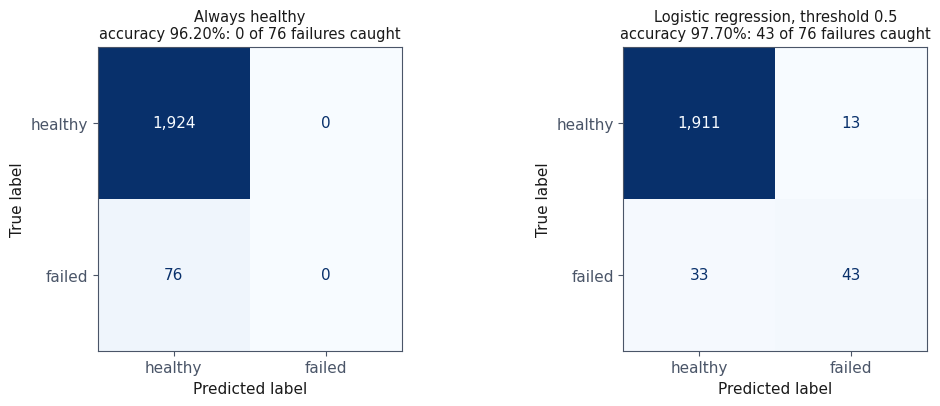

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, predicted, title in ((axes[0], always_healthy, "Always healthy"),
                             (axes[1], prediction, "Logistic regression, threshold 0.5")):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predicted, ax=ax, colorbar=False, cmap="Blues",
        display_labels=["healthy", "failed"], values_format=",d")
    accuracy = accuracy_score(y_test, predicted)
    caught = int(((predicted == 1) & (y_test == 1)).sum())
    ax.set_title(f"{title}\naccuracy {accuracy:.2%}: {caught} of "
                 f"{int(y_test.sum())} failures caught", fontsize=10.5)
fig.tight_layout()
fig.savefig(FIGURES / "confusion_matrix.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Put side by side, the two models are obviously not comparable — and the number
that separates them, 0 caught against 43 caught, is nowhere in the accuracy
figure.

Notice also the bottom-left cell of the right-hand matrix: **33 drives failed
and were called healthy.** That cell is the one to read first in any
confusion matrix for a problem like this, because it is the one that costs
most.

## 3. Precision, recall, and the question each one answers

Two ratios pull the four numbers apart. Both are quotients of the true
positives; they differ in what goes underneath.

$$\text{precision} = \frac{TP}{TP + FP} \qquad\qquad
  \text{recall} = \frac{TP}{TP + FN}$$

**Precision divides by everything we flagged.** It answers: *when this model
raises an alarm, how often is it right?* It is the technician's question — how
much of my time are you wasting?

**Recall divides by everything that was actually positive.** It answers: *of the
drives that were going to fail, how many did we find?* It is the operations
manager's question — how much am I still exposed to?

A memory hook that survives exam pressure: **precision is about the alarms,
recall is about the failures.** Look at the denominator and ask which population
you are dividing by.

In [5]:
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
f1 = 2 * precision * recall / (precision + recall)
specificity = true_negative / (true_negative + false_positive)

print(f"precision   {precision:.4f}   of the {true_positive + false_positive} drives we "
      f"flagged, {true_positive} really failed")
print(f"recall      {recall:.4f}   of the {true_positive + false_negative} drives that "
      f"failed, we caught {true_positive}")
print(f"F1          {f1:.4f}   harmonic mean of the two")
print(f"specificity {specificity:.4f}   of the {true_negative + false_positive} healthy "
      f"drives, we left {true_negative} alone")

print("\nand from scikit-learn, which agrees:")
print(f"precision {precision_score(y_test, prediction):.4f}   "
      f"recall {recall_score(y_test, prediction):.4f}   "
      f"f1 {f1_score(y_test, prediction):.4f}")

precision   0.7679   of the 56 drives we flagged, 43 really failed
recall      0.5658   of the 76 drives that failed, we caught 43
F1          0.6515   harmonic mean of the two
specificity 0.9932   of the 1924 healthy drives, we left 1911 alone

and from scikit-learn, which agrees:
precision 0.7679   recall 0.5658   f1 0.6515


**Why F1 uses the harmonic mean and not the ordinary one.** Consider a model
that flags every single drive: recall is a perfect 1.0, precision is 0.038. The
arithmetic mean of those is 0.519 — a respectable-looking score for a model that
is useless. The harmonic mean is 0.073.

The harmonic mean is dragged down by the smaller of the two numbers, which is
exactly the behaviour wanted: a model is only as good as its weaker side, and F1
refuses to let a perfect score on one axis buy a pass on the other.

In [6]:
flag_everything = np.ones(len(y_test), dtype=int)
p_all = precision_score(y_test, flag_everything)
r_all = recall_score(y_test, flag_everything)

print(f"flag every drive:  precision {p_all:.4f}   recall {r_all:.4f}")
print(f"  arithmetic mean  {(p_all + r_all) / 2:.4f}   <- flatters it")
print(f"  harmonic mean    {2 * p_all * r_all / (p_all + r_all):.4f}   <- F1, honest")

print("\nclassification_report gives all of it at once:")
print(classification_report(y_test, prediction,
                            target_names=["healthy", "failed"], digits=3))

flag every drive:  precision 0.0380   recall 1.0000
  arithmetic mean  0.5190   <- flatters it
  harmonic mean    0.0732   <- F1, honest

classification_report gives all of it at once:
              precision    recall  f1-score   support

     healthy      0.983     0.993     0.988      1924
      failed      0.768     0.566     0.652        76

    accuracy                          0.977      2000
   macro avg      0.875     0.780     0.820      2000
weighted avg      0.975     0.977     0.975      2000



Read the report the way a practitioner does: **go straight to the `failed`
row.** The `healthy` row is nearly perfect and always will be — it is the easy
majority class, and averaging it in is how a bad model gets a respectable
headline number.

That is also why the `macro avg` and `weighted avg` lines disagree so much.
`weighted avg` weights each class by how common it is, so it is dominated by the
healthy class and reads close to accuracy. `macro avg` gives the two classes
equal say, so the rare class actually registers. **When the classes are
imbalanced, quote the macro average or quote the minority class directly** —
never the weighted one, unless you want the number to look good.

## 4. The threshold is a choice, not a property of the model

Every number above depends on a decision we have not examined: predict "failing"
when the estimated probability is at least **0.5**.

That 0.5 has no special status. It is `predict()`'s default, and it is the right
choice only when the two errors cost the same and the classes are balanced —
neither of which is true here.

The model's actual output is a probability. Turning it into a decision requires
a threshold, and **choosing the threshold is a business decision, not a
statistical one.** Sweep it and watch.

In [7]:
rows = []
for threshold in (0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90):
    flagged = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, flagged).ravel()
    rows.append({
        "threshold": threshold, "flagged": int(flagged.sum()),
        "TP": tp, "FP": fp, "FN": fn,
        "precision": precision_score(y_test, flagged, zero_division=0),
        "recall": recall_score(y_test, flagged),
        "F1": f1_score(y_test, flagged, zero_division=0),
        "accuracy": accuracy_score(y_test, flagged),
    })

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

 threshold  flagged  TP  FP  FN  precision  recall    F1  accuracy
     0.020      353  69 284   7      0.195   0.908 0.322     0.855
     0.050      235  67 168   9      0.285   0.882 0.431     0.911
     0.100      163  61 102  15      0.374   0.803 0.510     0.942
     0.200      104  57  47  19      0.548   0.750 0.633     0.967
     0.300       78  53  25  23      0.679   0.697 0.688     0.976
     0.500       56  43  13  33      0.768   0.566 0.652     0.977
     0.700       34  30   4  46      0.882   0.395 0.545     0.975
     0.900       14  14   0  62      1.000   0.184 0.311     0.969


Read the table one column at a time and the whole trade-off is visible.

**Lower the threshold and recall rises, precision falls.** At 0.02 we catch 69
of the 76 failures — but we replace 284 healthy drives to do it. At 0.90 almost
every alarm is justified, and we catch fewer than a quarter of the failures.

**Accuracy is almost useless as a guide.** From threshold 0.2 upwards it sits
between 0.967 and 0.977 — a spread of one percentage point across models whose
recall ranges from 0.75 down to 0.18. And its maximum, 0.977, falls at the
default 0.5, which misses 33 of the 76 failures. Tune on accuracy and it will
quietly recommend catching fewer failures, because every alarm it drops was a
possible false positive.

**F1 peaks somewhere in the middle** — around 0.30 here — because it is the
metric that penalises both sides.

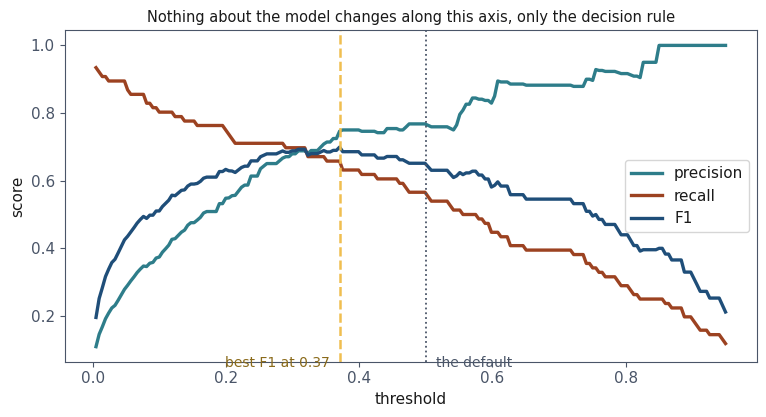

In [8]:
fine = np.linspace(0.005, 0.95, 200)
curves = {"precision": [], "recall": [], "F1": []}
for threshold in fine:
    flagged = (probability >= threshold).astype(int)
    curves["precision"].append(precision_score(y_test, flagged, zero_division=0))
    curves["recall"].append(recall_score(y_test, flagged))
    curves["F1"].append(f1_score(y_test, flagged, zero_division=0))

best = fine[int(np.argmax(curves["F1"]))]

fig, ax = plt.subplots(figsize=(7.8, 4.3))
for name, colour in (("precision", TEAL), ("recall", RUST), ("F1", BLUE)):
    ax.plot(fine, curves[name], lw=2.4, color=colour, label=name)
ax.axvline(0.5, color=SLATE, ls=":", lw=1.3)
ax.text(0.515, 0.05, "the default", color=SLATE, fontsize=10)
ax.axvline(best, color=GOLD, ls="--", lw=1.8)
ax.text(best - 0.015, 0.05, f"best F1 at {best:.2f}", color="#8a6a1a",
        fontsize=10, ha="right")
ax.set_xlabel("threshold"); ax.set_ylabel("score")
ax.set_title("Nothing about the model changes along this axis, only the "
             "decision rule", fontsize=10.5)
ax.legend(loc="center right")
fig.tight_layout()
fig.savefig(FIGURES / "threshold_sweep.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

The title of that figure is the point worth keeping. **The fitted model is
identical at every point on the x-axis.** The same coefficients, the same
probabilities, the same drives. All that changes is where we draw the line
between "leave it" and "replace it".

So when someone reports that their classifier has 77% precision, the honest
follow-up is: *at what threshold, and why that one?*

## 5. The precision-recall curve

The sweep above traces a path through (recall, precision) space. Plotting it
directly gives the **precision-recall curve**, which summarises every threshold
at once.

Its baseline is the useful part. A model that assigns random scores has
precision equal to the positive rate — **0.038 here** — at every recall. That
flat line, not 0.5, is what "no skill" looks like on an imbalanced problem, and
it is why a precision-recall curve is so much more informative than accuracy
when positives are rare.

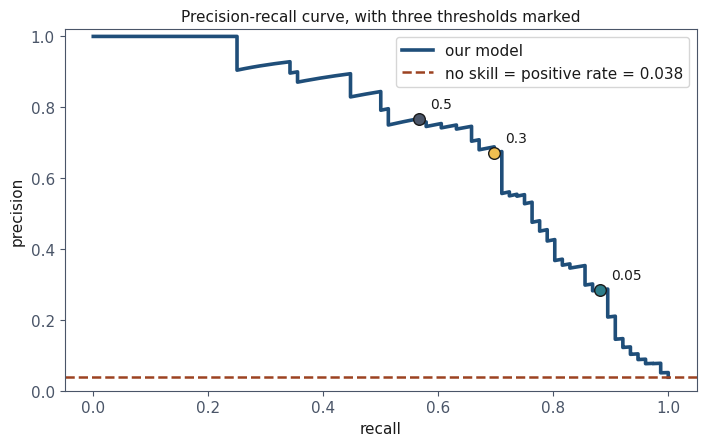

average precision (area under this curve): 0.717
a no-skill model would score:              0.038


In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_test, probability)
average_precision = average_precision_score(y_test, probability)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(recalls, precisions, lw=2.6, color=BLUE, label="our model")
ax.axhline(baseline, color=RUST, ls="--", lw=1.8,
           label=f"no skill = positive rate = {baseline:.3f}")

for threshold, colour in ((0.5, SLATE), (0.3, GOLD), (0.05, TEAL)):
    index = int(np.argmin(np.abs(thresholds - threshold)))
    ax.scatter(recalls[index], precisions[index], s=70, color=colour,
               edgecolor=INK, zorder=5)
    ax.annotate(f"{threshold:g}", (recalls[index], precisions[index]),
                textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision-recall curve, with three thresholds marked", fontsize=11)
ax.set_ylim(0, 1.02); ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES / "precision_recall_curve.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

print(f"average precision (area under this curve): {average_precision:.3f}")
print(f"a no-skill model would score:              {baseline:.3f}")

## What to take away

- **Accuracy on an imbalanced problem is close to useless.** 96.20% for a model
  that catches nothing; 97.70% for one that catches 43 of 76 failures. The gap
  between a real model and a worthless one was 1.5 points.
- The **confusion matrix** is the honest object. Read the false-negative cell
  first when misses are expensive.
- **Precision is about the alarms, recall is about the failures.** Check the
  denominator to remember which is which.
- **F1 is the harmonic mean** so that a perfect score on one axis cannot buy a
  pass on the other.
- On an imbalanced problem, report the **minority class or the macro average** —
  never the weighted average.
- The **threshold is a choice**, and every metric above depends on it. The model
  does not change as you move it.

Notebook 3 takes the last two points further: how to compare models without
picking a threshold at all, why the receiver operating characteristic
(ROC) curve — the standard tool for that —
quietly misleads on problems like this one, and how to choose the threshold from
costs rather than from habit.